In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual do Seaborn
sns.set_theme(style="whitegrid")

# Garantir que limpos_df está carregado
if 'limpos_df' not in globals():
    limpos = pd.read_excel('../../../Datasets/limpos_final.xlsm', sheet_name=None)
    sheet_names = list(limpos.keys())
    limpos_df = limpos[sheet_names[0]]

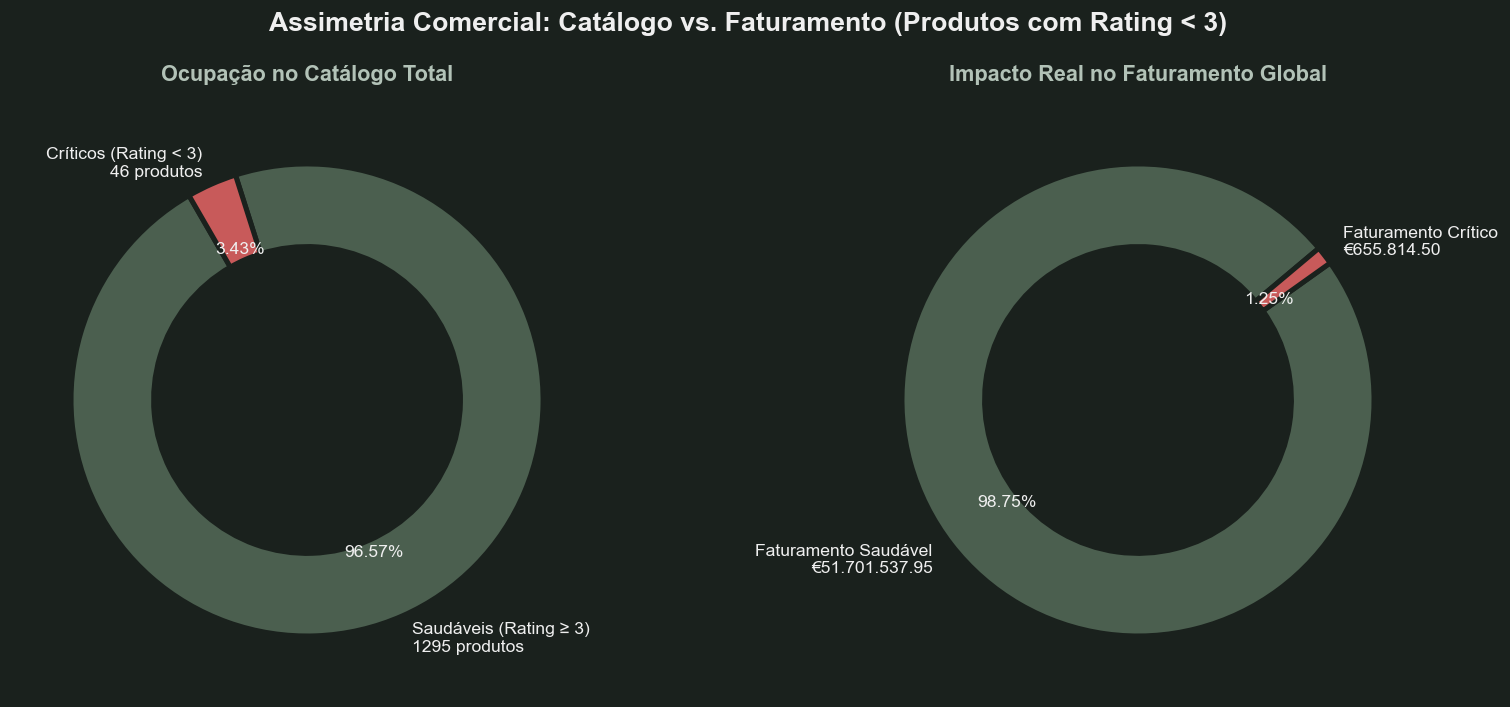

In [5]:
import pandas as pd
import matplotlib.pyplot as plt


# Garantir que limpos_df está carregado
if 'limpos_df' not in globals():
    limpos = pd.read_excel('../../../Datasets/limpos_final.xlsm', sheet_name=None)
    sheet_names = list(limpos.keys())
    limpos_df = limpos[sheet_names[0]]


limpos_df['rating_num'] = pd.to_numeric(limpos_df['rating'], errors='coerce')
limpos_df['price_num'] = pd.to_numeric(limpos_df['price'], errors='coerce')
limpos_df['units_sold_pure'] = pd.to_numeric(limpos_df['units_sold'], errors='coerce')

# 2. Filtragem de registros válidos
df_validos = limpos_df[
    (limpos_df['rating_num'] >= 1) & (limpos_df['rating_num'] <= 5) & 
    (limpos_df['price_num'].notna()) & (limpos_df['units_sold_pure'].notna())
].copy()

# 3. Cálculos de Receita e Divisão de Segmentos
df_validos['receita_produto'] = df_validos['price_num'] * df_validos['units_sold_pure']
receita_global_total = df_validos['receita_produto'].sum()

df_critico = df_validos[df_validos['rating_num'] < 3]
receita_critica = df_critico['receita_produto'].sum()

# Volumetria para o gráfico
total_itens = len(df_validos)
itens_criticos = len(df_critico)
itens_saudaveis = total_itens - itens_criticos
receita_saudavel = receita_global_total - receita_critica

# 4. Construção dos Gráficos (Estilo Verde Institucional / Fundo Escuro)
cor_fundo_slide = '#1A211D'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=120)
fig.patch.set_facecolor(cor_fundo_slide)

# Gráfico 1: Proporção de Itens no Catálogo
ax1.set_facecolor(cor_fundo_slide)
ax1.pie(
    [itens_saudaveis, itens_criticos], 
    labels=[f'Saudáveis (Rating ≥ 3)\n{itens_saudaveis} produtos', f'Críticos (Rating < 3)\n{itens_criticos} produtos'], 
    autopct='%1.2f%%', startangle=120, 
    colors=['#4B5F4F', '#C85A5A'], 
    textprops=dict(color="#EFEFEF", fontsize=10.5),
    pctdistance=0.70, wedgeprops=dict(width=0.35, edgecolor='#1A211D', linewidth=3)
)
ax1.set_title("Ocupação no Catálogo Total", color='#B2C2B7', fontsize=13, pad=15, weight='bold')

# Gráfico 2: Proporção de Faturamento
ax2.set_facecolor(cor_fundo_slide)
ax2.pie(
    [receita_saudavel, receita_critica], 
    labels=[f'Faturamento Saudável\n€{receita_saudavel:,.2f}'.replace(',', '.'), f'Faturamento Crítico\n€{receita_critica:,.2f}'.replace(',', '.')], 
    autopct='%1.2f%%', startangle=40, 
    colors=['#4B5F4F', '#C85A5A'],
    textprops=dict(color="#EFEFEF", fontsize=10.5),
    pctdistance=0.70, wedgeprops=dict(width=0.35, edgecolor='#1A211D', linewidth=3)
)
ax2.set_title("Impacto Real no Faturamento Global", color='#B2C2B7', fontsize=13, pad=15, weight='bold')

plt.suptitle("Assimetria Comercial: Catálogo vs. Faturamento (Produtos com Rating < 3)", color='#EFEFEF', fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

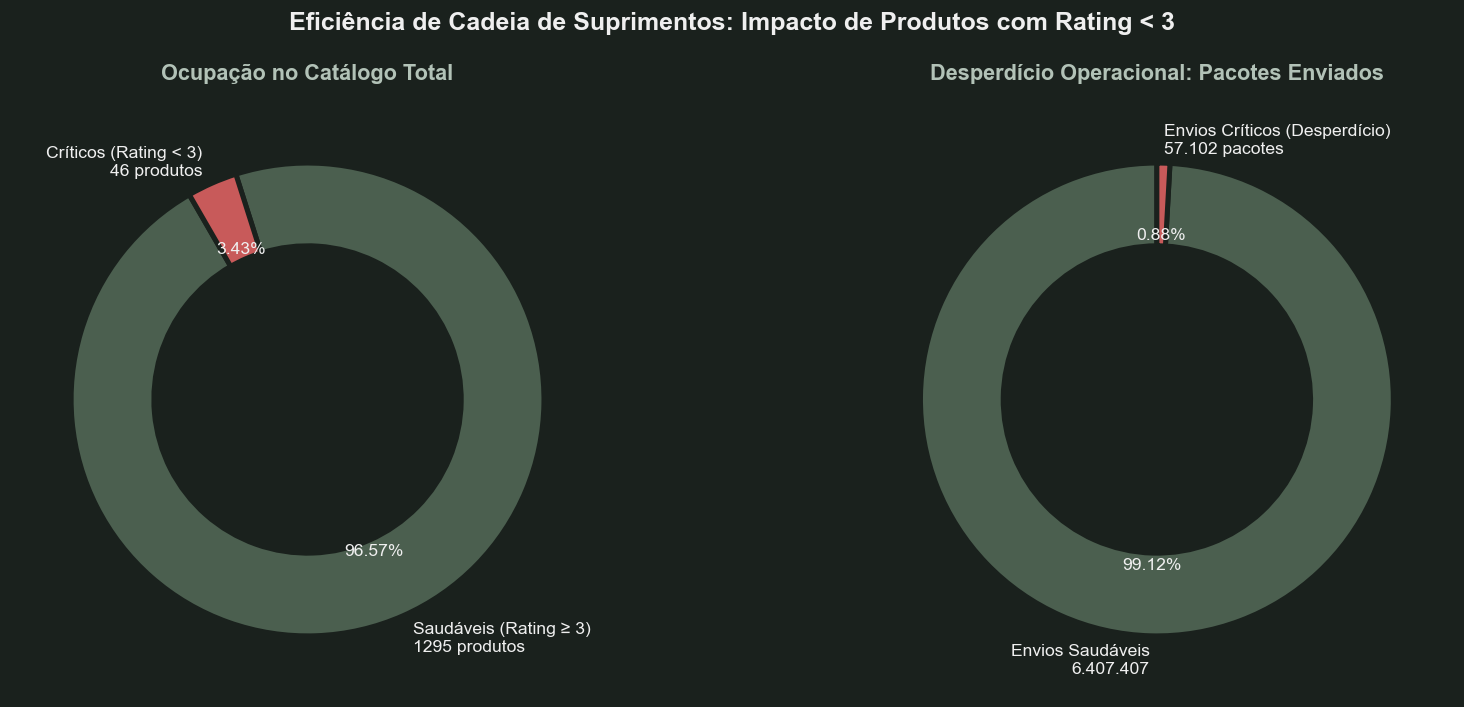

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Garantir o carregamento do DataFrame
if 'limpos_df' not in globals():
    limpos = pd.read_excel('limpos_final.xlsm', sheet_name=None)
    limpos_df = limpos[list(limpos.keys())[0]]

# Tratamento e conversão de tipos
limpos_df['rating_num'] = pd.to_numeric(limpos_df['rating'], errors='coerce')
limpos_df['units_sold_pure'] = pd.to_numeric(limpos_df['units_sold'], errors='coerce')

# Filtragem de registros consistentes
df_validos = limpos_df[
    (limpos_df['rating_num'] >= 1) & (limpos_df['rating_num'] <= 5) & 
    (limpos_df['units_sold_pure'].notna())
].copy()

# 2. Separação dos segmentos (Foco em Unidades / Pacotes)
df_critico = df_validos[df_validos['rating_num'] < 3]

# Volumetria de Itens (Catálogo)
itens_criticos = len(df_critico)
itens_saudaveis = len(df_validos) - itens_criticos

# Volumetria de Envios (Units Sold)
unidades_criticas = int(df_critico['units_sold_pure'].sum())
unidades_saudaveis = int(df_validos['units_sold_pure'].sum() - unidades_criticas)

# 3. Construção dos Gráficos (Estilo Fundo Escuro / Alta Resolução)
cor_fundo_slide = '#1A211D'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=120)
fig.patch.set_facecolor(cor_fundo_slide)

text_props = dict(color="#EFEFEF", fontsize=10.5)
cores = ['#4B5F4F', '#C85A5A'] # Verde Corporativo vs Vermelho de Risco

# Gráfico 1: Ocupação no Catálogo
ax1.set_facecolor(cor_fundo_slide)
ax1.pie(
    [itens_saudaveis, itens_criticos], 
    labels=[f'Saudáveis (Rating ≥ 3)\n{itens_saudaveis} produtos', f'Críticos (Rating < 3)\n{itens_criticos} produtos'], 
    autopct='%1.2f%%', startangle=120, colors=cores, textprops=text_props,
    pctdistance=0.70, wedgeprops=dict(width=0.35, edgecolor='#1A211D', linewidth=3)
)
ax1.set_title("Ocupação no Catálogo Total", color='#B2C2B7', fontsize=13, pad=15, weight='bold')

# Gráfico 2: Desperdício de Envios (Unidades Vendidas)
ax2.set_facecolor(cor_fundo_slide)
ax2.pie(
    [unidades_saudaveis, unidades_criticas], 
    labels=[f'Envios Saudáveis\n{unidades_saudaveis:,}'.replace(',', '.'), f'Envios Críticos (Desperdício)\n{unidades_criticas:,} pacotes'.replace(',', '.')], 
    autopct='%1.2f%%', startangle=90, colors=cores, textprops=text_props,
    pctdistance=0.70, wedgeprops=dict(width=0.35, edgecolor='#1A211D', linewidth=3)
)
ax2.set_title("Desperdício Operacional: Pacotes Enviados", color='#B2C2B7', fontsize=13, pad=15, weight='bold')

plt.suptitle("Eficiência de Cadeia de Suprimentos: Impacto de Produtos com Rating < 3", color='#EFEFEF', fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.savefig('desperdicio_pacotes_operacional.png', facecolor='#1A211D')
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=acb13dac-3e3d-49c3-81b9-b25c403473b5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>